In [ ]:
import pandas as pd
import random

# Sample names list
names = [
    "Sai", "Rahul", "Kiran", "Anil", "Ravi", "Suresh", "Mahesh", "Vamsi",
    "Teja", "Arjun", "Nikhil", "Varun", "Pavan", "Charan", "Lokesh",
    "Ramesh", "Naresh", "Ganesh", "Ajay", "Vijay",
    "Priya", "Anusha", "Divya", "Sneha", "Swathi", "Pooja", "Keerthi",
    "Lahari", "Harika", "Sravani", "Deepika", "Kavya", "Meghana",
    "Nandini", "Bhavya", "Aishwarya", "Shilpa", "Soujanya"
]

data = []

for i in range(1, 501):
    name = random.choice(names) + str(random.randint(1, 999))  # unique names
    mode = random.choice(["Online", "Offline"])
    online_rating = random.randint(2, 5)
    offline_rating = random.randint(3, 5)
    internet_issue = random.choice(["Yes", "No"])
    performance = random.randint(60, 90)

    # Logic: mostly offline preferred
    preferred = "Offline" if offline_rating >= online_rating else "Online"

    data.append([
        i, name, mode, online_rating, offline_rating,
        internet_issue, performance, preferred
    ])

df = pd.DataFrame(data, columns=[
    "Student_ID", "Name", "Mode",
    "Online_Rating", "Offline_Rating",
    "Internet_Issue", "Performance", "Preferred"
])

df.to_csv("students_500.csv", index=False)

print("File created successfully with student names!")

File created successfully with student names!


In [ ]:
import pandas as pd

df = pd.read_csv("students_500.csv")

# Remove duplicates
df = df.drop_duplicates()

# Handle missing values
df["Online_Rating"].fillna(df["Online_Rating"].mean(), inplace=True)
df["Offline_Rating"].fillna(df["Offline_Rating"].mean(), inplace=True)
df["Internet_Issue"].fillna("No", inplace=True)

# Fix text format
df["Mode"] = df["Mode"].str.strip().str.capitalize()
df["Preferred"] = df["Preferred"].str.strip().str.capitalize()
df["Name"] = df["Name"].str.strip()

# Remove invalid values
df = df[(df["Online_Rating"] >= 1) & (df["Online_Rating"] <= 5)]
df = df[(df["Offline_Rating"] >= 1) & (df["Offline_Rating"] <= 5)]
df = df[(df["Performance"] >= 0) & (df["Performance"] <= 100)]

# Save cleaned data
df.to_csv("cleaned_students.csv", index=False)

print("Data cleaned successfully!")

Data cleaned successfully!


/tmp/ipykernel_2774/2305011750.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Online_Rating"].fillna(df["Online_Rating"].mean(), inplace=True)
/tmp/ipykernel_2774/2305011750.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("cleaned_students.csv")
print(df.head())

   Student_ID        Name     Mode  Online_Rating  Offline_Rating  \
0           1     Sneha74  Offline              3               5   
1           2      Sai989  Offline              2               3   
2           3  Keerthi232  Offline              4               5   
3           4     Ramesh7  Offline              5               5   
4           5   Lahari942   Online              4               3   

  Internet_Issue  Performance Preferred  
0             No           61   Offline  
1             No           73   Offline  
2            Yes           75   Offline  
3             No           76   Offline  
4             No           83    Online  


In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Student_ID      500 non-null    int64 
 1   Name            500 non-null    object
 2   Mode            500 non-null    object
 3   Online_Rating   500 non-null    int64 
 4   Offline_Rating  500 non-null    int64 
 5   Internet_Issue  500 non-null    object
 6   Performance     500 non-null    int64 
 7   Preferred       500 non-null    object
dtypes: int64(4), object(4)
memory usage: 31.4+ KB
None
       Student_ID  Online_Rating  Offline_Rating  Performance
count  500.000000     500.000000      500.000000    500.00000
mean   250.500000       3.524000        3.966000     74.51000
std    144.481833       1.143696        0.811271      8.84434
min      1.000000       2.000000        3.000000     60.00000
25%    125.750000       2.000000        3.000000     67.00000
50%    250.500000       4.00

In [ ]:
df = df.drop_duplicates()
df.fillna(0, inplace=True)

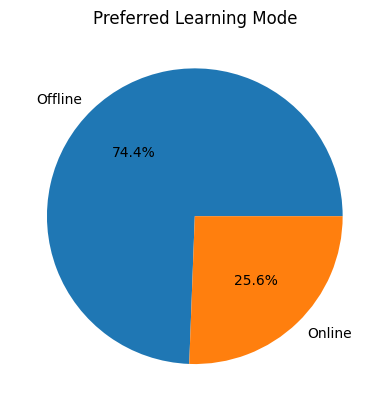

In [ ]:
df['Preferred'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Preferred Learning Mode")
plt.ylabel("")
plt.show()

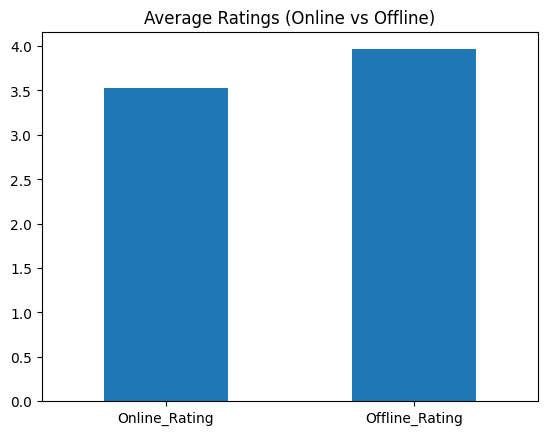

In [ ]:
ratings = df[['Online_Rating','Offline_Rating']].mean()
ratings.plot.bar()
plt.title("Average Ratings (Online vs Offline)")
plt.xticks(rotation=0)
plt.show()

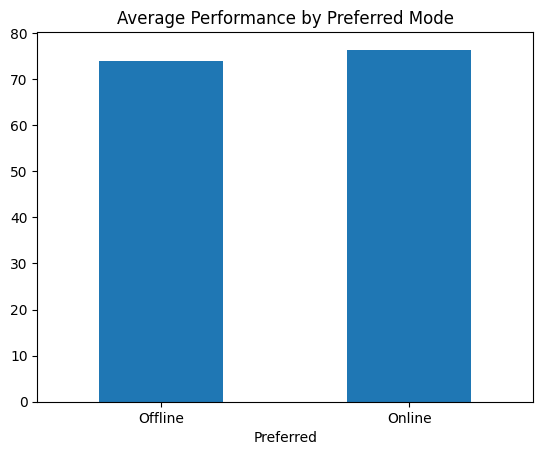

In [ ]:
performance = df.groupby('Preferred')['Performance'].mean()
performance.plot.bar()
plt.title("Average Performance by Preferred Mode")
plt.xticks(rotation=0)
plt.show()

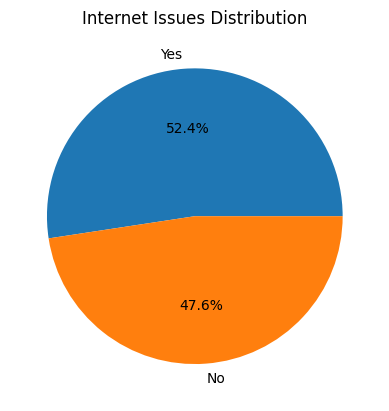

In [ ]:
df['Internet_Issue'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Internet Issues Distribution")
plt.ylabel("")
plt.show()

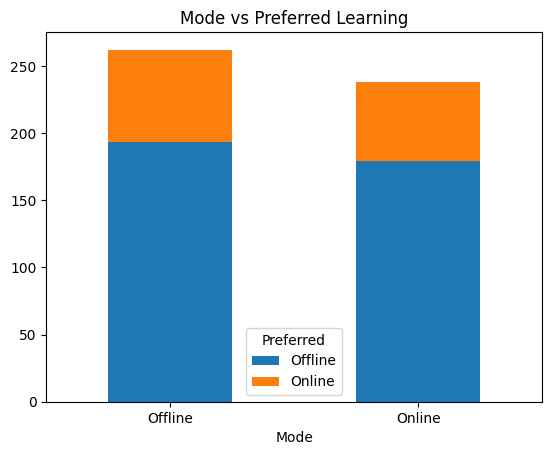

In [ ]:
cross = pd.crosstab(df['Mode'], df['Preferred'])
cross.plot(kind='bar', stacked=True)
plt.title("Mode vs Preferred Learning")
plt.xticks(rotation=0)
plt.show()

In [ ]:
total_students = len(df)
offline_percent = (df['Preferred'].value_counts(normalize=True) * 100).get('Offline', 0)
avg_online = df['Online_Rating'].mean()
avg_offline = df['Offline_Rating'].mean()

print("----- KPI SUMMARY -----")
print("Total Students:", total_students)
print("Offline Preference %:", round(offline_percent,2))
print("Average Online Rating:", round(avg_online,2))
print("Average Offline Rating:", round(avg_offline,2))

----- KPI SUMMARY -----
Total Students: 500
Offline Preference %: 74.4
Average Online Rating: 3.52
Average Offline Rating: 3.97
